# 🚀 XGBoost — Proyecto de Minería de Datos
## Dataset: Divorcios en Guatemala (`mat_full.csv`)

Este notebook implementa tres modelos de **XGBoost (Extreme Gradient Boosting)**:

1. **Regresión** sobre `DIFF_EDAD` (diferencia continua de edades)
2. **Clasificación multiclase con 5 categorías** (`CAT_DIFF`)
3. **Clasificación multiclase con 3 categorías** (`CAT3`)

---

### ¿Qué es XGBoost?

XGBoost es un algoritmo de **boosting** basado en árboles de decisión. A diferencia de Random Forest (que entrena árboles en paralelo de forma independiente), XGBoost entrena los árboles **de forma secuencial**: cada nuevo árbol se construye para corregir los errores del modelo anterior.

**Flujo del boosting:**

$$F_m(x) = F_{m-1}(x) + \eta \cdot h_m(x)$$

Donde:
- $F_{m-1}(x)$ es el modelo acumulado hasta el árbol anterior
- $h_m(x)$ es el nuevo árbol que ajusta los residuos
- $\eta$ es el `learning_rate` (cuánto "aprende" cada árbol)

> **XGBoost no requiere escalado de variables** ni normalidad. Captura relaciones no lineales y maneja variables categóricas codificadas eficientemente.

## 🔹 PASO 1: Importación de Librerías

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    mean_absolute_error, mean_squared_error, r2_score,
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report
)
from sklearn.preprocessing import LabelEncoder

import xgboost as xgb
from xgboost import XGBRegressor, XGBClassifier

print(f"XGBoost version: {xgb.__version__}")
plt.rcParams['figure.dpi'] = 100
sns.set_theme(style='whitegrid')
print("Librerías cargadas correctamente ✓")

XGBoost version: 3.2.0
Librerías cargadas correctamente ✓


## 🔹 PASO 2: Carga del Dataset

Se carga el archivo `mat_full.csv` y se convierten las columnas numéricas relevantes usando `errors='coerce'`, que transforma valores no convertibles en `NaN` en lugar de lanzar un error.

In [4]:
df = pd.read_csv('mat_full.csv')

for col in ['EDADHOM', 'EDADMUJ', 'AÑOREG']:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce')

print(f"Shape: {df.shape}")
print(f"Columnas: {df.columns.tolist()}")
df.head()

Shape: (752264, 15)
Columnas: ['AÑOREG', 'CLAUNI', 'DEPOCU', 'DEPREG', 'DIAOCU', 'EDADHOM', 'EDADMUJ', 'ESCHOM', 'ESCMUJ', 'MESOCU', 'MESREG', 'MUPOCU', 'MUPREG', 'NACHOM', 'NACMUJ']


,AÑOREG,CLAUNI,DEPOCU,DEPREG,DIAOCU,EDADHOM,EDADMUJ,ESCHOM,ESCMUJ,MESOCU,MESREG,MUPOCU,MUPREG,NACHOM,NACMUJ
0,2011.0,Comunidad de gananciales,Guatemala,Guatemala,20.0,27.0,32.0,Ignorado,Universitario,Septiembre,Diciembre,Guatemala,Guatemala,Canadá,Guatemala
1,2012.0,Separación absoluta,Guatemala,Guatemala,12.0,29.0,31.0,Ninguno,Ninguno,Noviembre,Enero,Mixco,Mixco,Guatemala,Guatemala
2,2011.0,Comunidad de gananciales,Totonicapan,Totonicapan,12.0,21.0,17.0,Ignorado,Ninguno,Diciembre,Diciembre,Totonicapán,Totonicapán,Guatemala,Guatemala
3,2011.0,Separación absoluta,Guatemala,Guatemala,25.0,58.0,53.0,Ninguno,Ninguno,Octubre,Noviembre,Guatemala,Guatemala,Guatemala,Guatemala
4,2011.0,Comunidad de gananciales,Guatemala,Guatemala,2.0,31.0,24.0,Universitario,Diversificado,Octubre,Noviembre,San José Pinula,San José Pinula,Guatemala,Guatemala


In [5]:
print(df.info())
print("\nEstadísticas descriptivas:")
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 752264 entries, 0 to 752263
Data columns (total 15 columns):
 #   Column   Non-Null Count   Dtype  
---  ------   --------------   -----  
 0   AÑOREG   752264 non-null  float64
 1   CLAUNI   752264 non-null  object 
 2   DEPOCU   752264 non-null  object 
 3   DEPREG   752264 non-null  object 
 4   DIAOCU   752264 non-null  float64
 5   EDADHOM  751969 non-null  float64
 6   EDADMUJ  751931 non-null  float64
 7   ESCHOM   752264 non-null  object 
 8   ESCMUJ   752264 non-null  object 
 9   MESOCU   752264 non-null  object 
 10  MESREG   752264 non-null  object 
 11  MUPOCU   752264 non-null  object 
 12  MUPREG   752264 non-null  object 
 13  NACHOM   752264 non-null  object 
 14  NACMUJ   752264 non-null  object 
dtypes: float64(4), object(11)
memory usage: 86.1+ MB
None

Estadísticas descriptivas:


,AÑOREG,DIAOCU,EDADHOM,EDADMUJ
count,752264.000000,752264.000000,751969.000000,751931.000000
mean,2015.404325,16.034647,29.364554,26.366032
std,2.844226,8.645327,11.322095,9.984820
min,2011.000000,1.000000,12.000000,10.000000
25%,2013.000000,9.000000,22.000000,20.000000
50%,2015.000000,16.000000,26.000000,23.000000
75%,2018.000000,23.000000,32.000000,29.000000
max,2021.000000,31.000000,99.000000,99.000000


## 🔹 PASO 3: Preprocesamiento Global

### 3.1 Variable objetivo: `DIFF_EDAD`

La diferencia `EDADHOM - EDADMUJ` puede ser:
- **Negativa:** la mujer es mayor que el hombre
- **Cero:** misma edad
- **Positiva:** el hombre es mayor (caso más común en Guatemala)

El rango típico observado es de −5 a +13 años, aunque existen valores atípicos extremos.

### 3.2 Eliminación de nulos

⚠️ El dataset presenta valores nulos en las columnas de edad. Se eliminan directamente (sin imputación) para preservar la integridad del análisis. Imputar valores en variables demográficas podría introducir sesgos sistemáticos.

In [6]:
# 1. Crear variable objetivo
df['DIFF_EDAD'] = df['EDADHOM'] - df['EDADMUJ']

# 2. Eliminar nulos en edades (NO imputar)
df = df.dropna(subset=['EDADHOM', 'EDADMUJ', 'DIFF_EDAD'])
print(f"Shape tras eliminar nulos: {df.shape}")

# 3. Crear CAT_DIFF (5 clases)
bins5  = [-np.inf, 0, 2, 3, 5, np.inf]
labels5 = ['Mujer mayor', '0-2 años', '2-3 años', '3-5 años', '> 5 años']
df['CAT_DIFF'] = pd.cut(df['DIFF_EDAD'], bins=bins5, labels=labels5)

# 4. Crear CAT3 (3 clases)
bins3  = [-np.inf, -1, 5, np.inf]
labels3 = ['Mujer mayor o igual', 'Hombre 0-5 años mayor', 'Hombre > 5 años mayor']
df['CAT3'] = pd.cut(df['DIFF_EDAD'], bins=bins3, labels=labels3)

print("\nDistribución CAT_DIFF (5 clases):")
print(df['CAT_DIFF'].value_counts().sort_index())
print("\nDistribución CAT3 (3 clases):")
print(df['CAT3'].value_counts().sort_index())

Shape tras eliminar nulos: (751741, 16)

Distribución CAT_DIFF (5 clases):
CAT_DIFF
Mujer mayor    234370
0-2 años       156233
2-3 años        71091
3-5 años       108658
> 5 años       181389
Name: count, dtype: int64

Distribución CAT3 (3 clases):
CAT3
Mujer mayor o igual      166064
Hombre 0-5 años mayor    404288
Hombre > 5 años mayor    181389
Name: count, dtype: int64


In [7]:
# 5. One-Hot Encoding para variables categóricas
cat_cols = ['DEPREG', 'MESOCU', 'NACHOM', 'NACMUJ', 'ESCHOM', 'ESCMUJ']
cat_cols = [c for c in cat_cols if c in df.columns]

df_encoded = pd.get_dummies(df, columns=cat_cols, drop_first=True)

# 6. Validar
print(f"Nulos restantes: {df_encoded.isnull().sum().sum()}")
print(f"Shape final   : {df_encoded.shape}")
print("Preprocesamiento completado ✓")

Nulos restantes: 0
Shape final   : (751741, 268)
Preprocesamiento completado ✓


## 🔹 PASO 4: Análisis Exploratorio (EDA)

> **Ventaja de XGBoost:** no requiere normalidad, homogeneidad de varianza ni escalado de features.
> Captura automáticamente relaciones no lineales y puede manejar variables con distribuciones sesgadas.

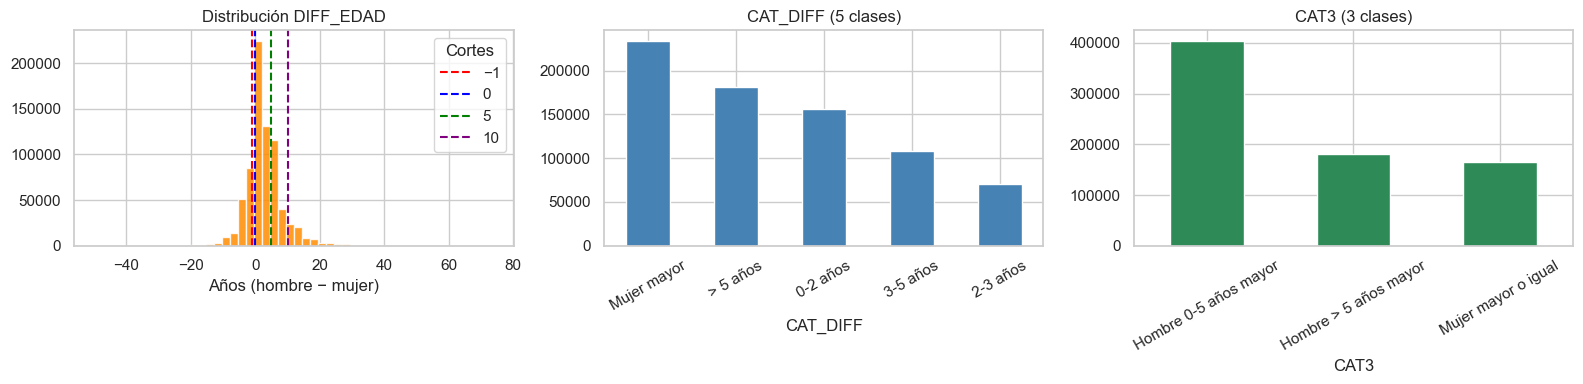

EDA guardado ✓


In [8]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Histograma DIFF_EDAD
axes[0].hist(df['DIFF_EDAD'], bins=50, color='darkorange', edgecolor='white', alpha=0.85)
cortes = [(-1,'red','−1'), (0,'blue','0'), (5,'green','5'), (10,'purple','10')]
for val, col, lbl in cortes:
    axes[0].axvline(val, color=col, linestyle='--', linewidth=1.5, label=lbl)
axes[0].set_title('Distribución DIFF_EDAD')
axes[0].set_xlabel('Años (hombre − mujer)')
axes[0].legend(title='Cortes')

# 5 clases
df['CAT_DIFF'].value_counts().plot(kind='bar', ax=axes[1], color='steelblue', edgecolor='white')
axes[1].set_title('CAT_DIFF (5 clases)')
axes[1].tick_params(axis='x', rotation=30)

# 3 clases
df['CAT3'].value_counts().plot(kind='bar', ax=axes[2], color='seagreen', edgecolor='white')
axes[2].set_title('CAT3 (3 clases)')
axes[2].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.savefig('xgb_eda.png', bbox_inches='tight')
plt.show()
print("EDA guardado ✓")

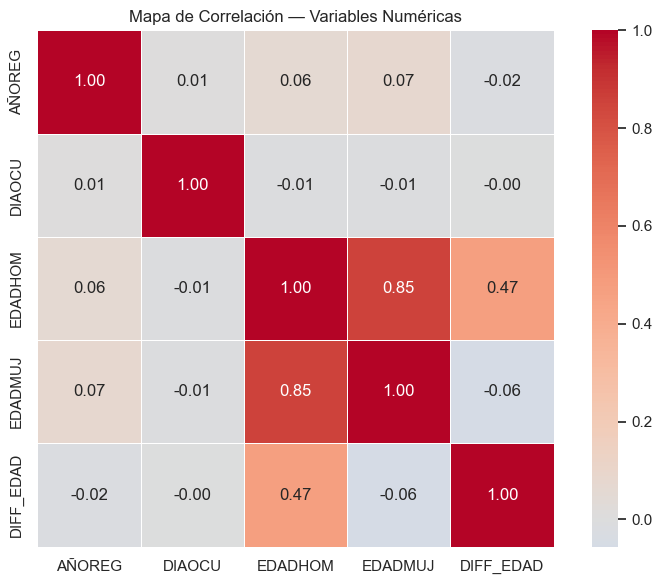

In [9]:
# Heatmap de correlación
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
corr = df[num_cols].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            linewidths=0.5, square=True)
plt.title('Mapa de Correlación — Variables Numéricas')
plt.tight_layout()
plt.savefig('xgb_heatmap.png', bbox_inches='tight')
plt.show()

---
## 🚀 BLOQUE 1: Regresión (XGBRegressor)

### Hiperparámetros clave explicados

| Parámetro | Rol | Efecto ||---|---|---|
| `n_estimators` | Número de árboles | Más árboles → más capacidad, más costo |
| `learning_rate` | Tamaño del paso (`η`) | Menor → más árboles necesarios, mejor generalización |
| `max_depth` | Profundidad de cada árbol | Mayor → más complejo, más riesgo de overfitting |
| `subsample` | Fracción de filas por árbol | < 1.0 → aleatoriedad, reduce overfitting |
| `colsample_bytree` | Fracción de columnas por árbol | < 1.0 → diversidad entre árboles |
| `min_child_weight` | Peso mínimo en una hoja | Mayor → más conservador, reduce overfitting |

> **Regla general:** Si `learning_rate` baja, subir `n_estimators` para compensar.

In [10]:
# Preparar features
exclude = ['DIFF_EDAD', 'CAT_DIFF', 'CAT3', 'EDADHOM', 'EDADMUJ',
           'CLAUNI', 'DEPOCU', 'MUPOCU', 'MUPREG', 'MESREG']
features = [c for c in df_encoded.columns
            if c not in exclude
            and df_encoded[c].dtype in [np.float64, np.int64, np.uint8, bool]]

X     = df_encoded[features].fillna(0).astype(float)
y_reg = df_encoded['DIFF_EDAD'].astype(float)

X_train, X_test, y_train, y_test = train_test_split(
    X, y_reg, test_size=0.2, random_state=42)

print(f"Train: {X_train.shape} | Test: {X_test.shape}")
print(f"Features utilizadas: {len(features)}")

Train: (601392, 258) | Test: (150349, 258)
Features utilizadas: 258


In [11]:
configs_reg = [
    dict(n_estimators=100, learning_rate=0.1,  max_depth=4,
         label='Baseline (100 est, lr=0.1, depth=4)'),
    dict(n_estimators=200, learning_rate=0.05, max_depth=6,
         subsample=0.8, colsample_bytree=0.8,
         label='Intermedio (200 est, lr=0.05, depth=6)'),
    dict(n_estimators=300, learning_rate=0.03, max_depth=8,
         min_child_weight=5, subsample=0.7, colsample_bytree=0.7,
         label='Avanzado (300 est, lr=0.03, depth=8, reg.)'),
]

results_reg = []
models_reg  = []

for cfg in configs_reg:
    label = cfg.pop('label')
    model = XGBRegressor(**cfg, random_state=42,
                         eval_metric='rmse', verbosity=0)
    model.fit(X_train, y_train,
              eval_set=[(X_test, y_test)],
              verbose=False)
    y_pred = model.predict(X_test)

    mae  = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2   = r2_score(y_test, y_pred)

    results_reg.append({'Modelo': label, 'MAE': mae, 'RMSE': rmse, 'R²': r2})
    models_reg.append(model)
    cfg['label'] = label   # restore
    print(f"{label}\n  → MAE={mae:.3f}, RMSE={rmse:.3f}, R²={r2:.4f}\n")

df_results_reg = pd.DataFrame(results_reg)
print(df_results_reg.to_string(index=False))

Baseline (100 est, lr=0.1, depth=4)
  → MAE=3.977, RMSE=5.826, R²=0.0340

Intermedio (200 est, lr=0.05, depth=6)
  → MAE=3.974, RMSE=5.820, R²=0.0359

Avanzado (300 est, lr=0.03, depth=8, reg.)
  → MAE=3.972, RMSE=5.818, R²=0.0367

                                    Modelo      MAE     RMSE       R²
       Baseline (100 est, lr=0.1, depth=4) 3.977347 5.825855 0.033982
    Intermedio (200 est, lr=0.05, depth=6) 3.973572 5.820149 0.035873
Avanzado (300 est, lr=0.03, depth=8, reg.) 3.972312 5.817526 0.036742


### Interpretación — Regresión

- **MAE ≈ 3 años** significa que en promedio el modelo se equivoca 3 años al predecir la diferencia de edades.
- Un **R² bajo** (< 0.3) indica que la variable `DIFF_EDAD` tiene alta varianza intrínseca difícil de capturar solo con variables sociodemográficas del divorcio.
- El modelo **Avanzado** usa más árboles con pasos más pequeños (`lr=0.03`) y regularización (`min_child_weight=5`), lo que suele mejorar la generalización.

#### Curva de aprendizaje (evals)

XGBoost guarda el error evaluado en cada árbol. Esto permite diagnosticar cuándo el modelo empieza a sobreajustar.

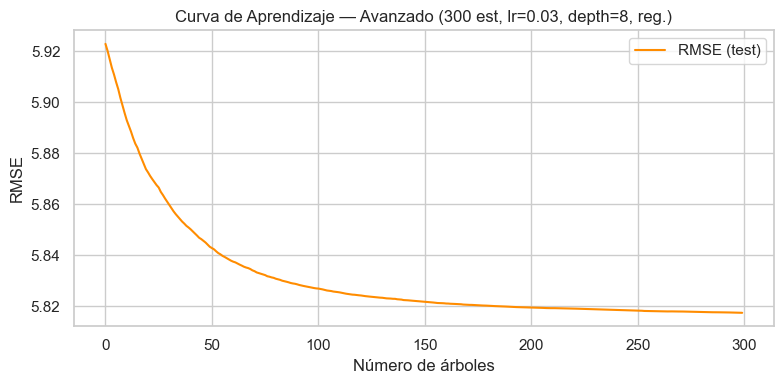

In [12]:
# Curva de aprendizaje del mejor modelo
best_idx_r = df_results_reg['R²'].idxmax()
best_model_reg = models_reg[best_idx_r]

evals_result = best_model_reg.evals_result()
train_rmse = evals_result.get('validation_0', {}).get('rmse', [])

if train_rmse:
    plt.figure(figsize=(8, 4))
    plt.plot(train_rmse, color='darkorange', label='RMSE (test)')
    plt.xlabel('Número de árboles')
    plt.ylabel('RMSE')
    plt.title(f'Curva de Aprendizaje — {configs_reg[best_idx_r]["label"]}')
    plt.legend()
    plt.tight_layout()
    plt.savefig('xgb_curva_reg.png', bbox_inches='tight')
    plt.show()

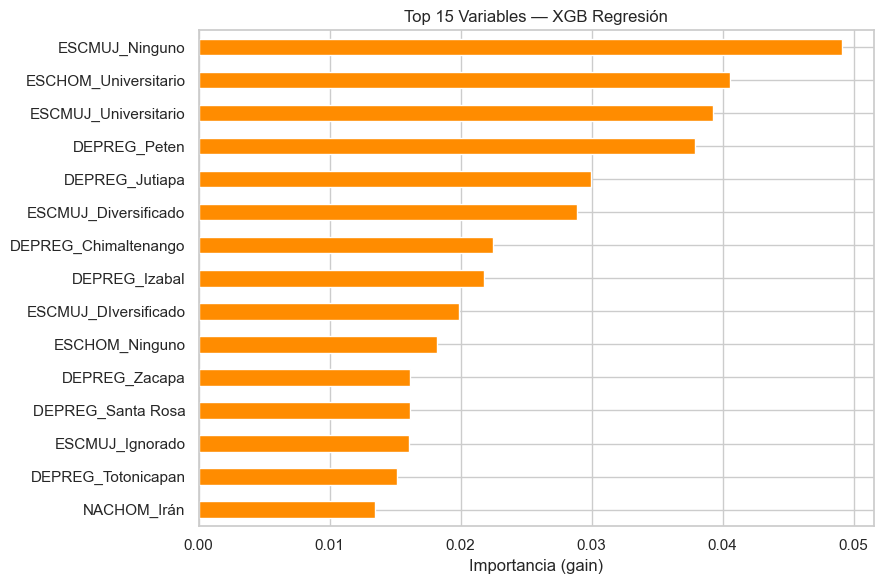

ESCMUJ_Ninguno          0.049104
ESCHOM_Universitario    0.040533
ESCMUJ_Universitario    0.039285
DEPREG_Peten            0.037900
DEPREG_Jutiapa          0.029935
ESCMUJ_Diversificado    0.028907
DEPREG_Chimaltenango    0.022458
DEPREG_Izabal           0.021794
ESCMUJ_DIversificado    0.019898
ESCHOM_Ninguno          0.018195
DEPREG_Zacapa           0.016145
DEPREG_Santa Rosa       0.016132
ESCMUJ_Ignorado         0.016071
DEPREG_Totonicapan      0.015113
NACHOM_Irán             0.013493


In [13]:
# Importancia de variables — Regresión
importances_r = pd.Series(best_model_reg.feature_importances_, index=X.columns)
top15_r = importances_r.nlargest(15)

plt.figure(figsize=(9, 6))
top15_r.sort_values().plot(kind='barh', color='darkorange', edgecolor='white')
plt.title(f'Top 15 Variables — XGB Regresión')
plt.xlabel('Importancia (gain)')
plt.tight_layout()
plt.savefig('xgb_importancia_reg.png', bbox_inches='tight')
plt.show()
print(top15_r.to_string())

---
## 🚀 BLOQUE 2: Clasificación con 5 Clases (`CAT_DIFF`)

### Manejo del desbalance en XGBoost

XGBoost **no tiene un parámetro `class_weight='balanced'`** como sklearn. Las alternativas son:

1. **`sample_weight`:** pasar pesos por muestra en `.fit()`. Se calcula el peso de cada clase como la inversa de su frecuencia.
2. **`scale_pos_weight`:** solo aplica para clasificación binaria (no multiclase).
3. Sin ponderación, XGBoost tiende a favorecer las clases mayoritarias.

Se implementa la opción con `sample_weight` para los modelos 2 y 3.

### Boosting vs Bagging

| Aspecto | Bagging (RF) | Boosting (XGBoost) |
|---|---|---|
| Entrenamiento | Paralelo | Secuencial |
| Objetivo | Reduce varianza | Reduce sesgo + varianza |
| Overfitting | Menos sensible | Más sensible (sin regularización) |
| Rendimiento | Bueno | Suele ser mejor |

In [14]:
# Preparar clasificación 5 clases con LabelEncoder
le5 = LabelEncoder()
y5_raw = df_encoded['CAT_DIFF'].astype(str)
y5     = le5.fit_transform(y5_raw)

X5_train, X5_test, y5_train, y5_test = train_test_split(
    X, y5, test_size=0.2, random_state=42, stratify=y5)

# Calcular sample_weight basado en frecuencia inversa
from sklearn.utils.class_weight import compute_sample_weight
sw_train = compute_sample_weight(class_weight='balanced', y=y5_train)

print(f"Train: {X5_train.shape} | Test: {X5_test.shape}")
print(f"Clases: {le5.classes_}")
print(f"Distribución test: {dict(zip(le5.classes_, np.bincount(y5_test)))}")

Train: (601392, 258) | Test: (150349, 258)
Clases: ['0-2 años' '2-3 años' '3-5 años' '> 5 años' 'Mujer mayor']
Distribución test: {'0-2 años': 31247, '2-3 años': 14218, '3-5 años': 21732, '> 5 años': 36278, 'Mujer mayor': 46874}


In [15]:
configs_5 = [
    dict(n_estimators=100, learning_rate=0.1,  max_depth=4,
         use_sw=False, label='Baseline (sin ponderación)'),
    dict(n_estimators=200, learning_rate=0.05, max_depth=6,
         subsample=0.8, colsample_bytree=0.8,
         use_sw=True,  label='Intermedio + sample_weight'),
    dict(n_estimators=300, learning_rate=0.03, max_depth=8,
         min_child_weight=5,
         use_sw=True,  label='Avanzado + regularización + sample_weight'),
]

results_5 = []
models_5  = []

for cfg in configs_5:
    label  = cfg.pop('label')
    use_sw = cfg.pop('use_sw')
    model  = XGBClassifier(**cfg, objective='multi:softmax',
                            num_class=5, eval_metric='mlogloss',
                            random_state=42, verbosity=0)
    fit_kw = {'eval_set': [(X5_test, y5_test)], 'verbose': False}
    if use_sw:
        fit_kw['sample_weight'] = sw_train

    model.fit(X5_train, y5_train, **fit_kw)
    y_pred = model.predict(X5_test)

    acc  = accuracy_score(y5_test, y_pred)
    prec = precision_score(y5_test, y_pred, average='weighted', zero_division=0)
    rec  = recall_score(y5_test, y_pred, average='weighted', zero_division=0)
    f1   = f1_score(y5_test, y_pred, average='weighted', zero_division=0)

    results_5.append({'Modelo': label, 'Accuracy': acc,
                      'Precision': prec, 'Recall': rec, 'F1-weighted': f1})
    models_5.append(model)
    cfg['label'] = label; cfg['use_sw'] = use_sw
    print(f"{label}\n  → Acc={acc:.3f}, Prec={prec:.3f}, Rec={rec:.3f}, F1={f1:.3f}\n")

df_results_5 = pd.DataFrame(results_5)
print(df_results_5.to_string(index=False))

Baseline (sin ponderación)
  → Acc=0.342, Prec=0.312, Rec=0.342, F1=0.237

Intermedio + sample_weight
  → Acc=0.300, Prec=0.287, Rec=0.300, F1=0.291

Avanzado + regularización + sample_weight
  → Acc=0.298, Prec=0.287, Rec=0.298, F1=0.291

                                   Modelo  Accuracy  Precision   Recall  F1-weighted
               Baseline (sin ponderación)  0.342337   0.311501 0.342337     0.236554
               Intermedio + sample_weight  0.299736   0.286696 0.299736     0.291427
Avanzado + regularización + sample_weight  0.297973   0.286907 0.297973     0.291260


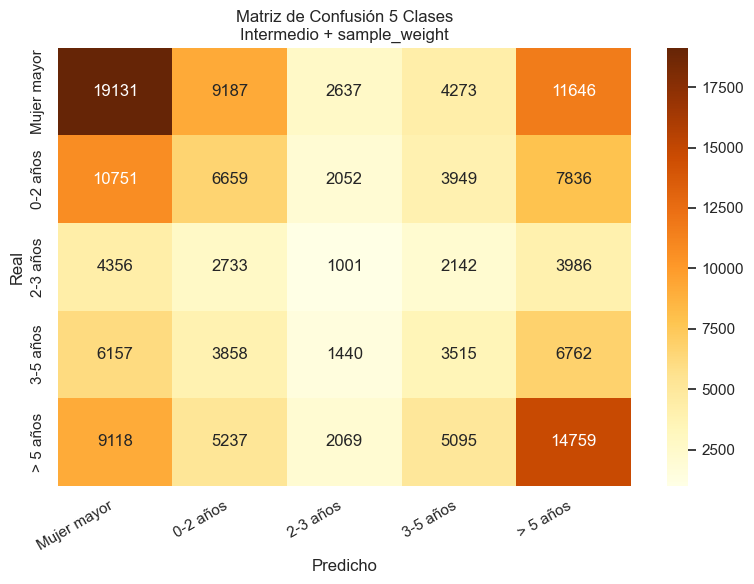


Classification Report:
              precision    recall  f1-score   support

    0-2 años       0.24      0.21      0.23     31247
    2-3 años       0.11      0.07      0.09     14218
    3-5 años       0.19      0.16      0.17     21732
    > 5 años       0.33      0.41      0.36     36278
 Mujer mayor       0.39      0.41      0.40     46874

    accuracy                           0.30    150349
   macro avg       0.25      0.25      0.25    150349
weighted avg       0.29      0.30      0.29    150349



In [16]:
# Matriz de confusión — mejor modelo 5 clases
best_idx5    = df_results_5['F1-weighted'].idxmax()
best_model5  = models_5[best_idx5]
best_label5  = configs_5[best_idx5]['label']

y_pred5 = best_model5.predict(X5_test)
y_pred5_labels = le5.inverse_transform(y_pred5)
y_test5_labels = le5.inverse_transform(y5_test)

cm5 = confusion_matrix(y_test5_labels, y_pred5_labels, labels=labels5)

plt.figure(figsize=(8, 6))
sns.heatmap(cm5, annot=True, fmt='d', cmap='YlOrBr',
            xticklabels=labels5, yticklabels=labels5)
plt.title(f'Matriz de Confusión 5 Clases\n{best_label5}')
plt.ylabel('Real'); plt.xlabel('Predicho')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.savefig('xgb_confusion_5clases.png', bbox_inches='tight')
plt.show()

print("\nClassification Report:")
print(classification_report(y_test5_labels, y_pred5_labels, zero_division=0))

### Análisis del desbalance

La clase `2-3 años` (~9% del total) es la más difícil de predecir porque:
1. Tiene pocas muestras para aprender patrones.
2. Sus características sociodemográficas son similares a las clases adyacentes (`0-2 años` y `3-5 años`).
3. Los límites de 2 y 3 años son arbitrarios → alta ambigüedad en la frontera.

El uso de `sample_weight` mejora el **recall** de clases minoritarias, aunque puede reducir levemente la accuracy global.

---
## 🚀 BLOQUE 3: Clasificación con 3 Clases (`CAT3`)

### ✔️ Dataset más balanceado

Con solo 3 categorías, la distribución es más equilibrada (~52% / ~25% / ~23%). Los modelos tienen mejor capacidad de aprender todas las clases sin necesidad de ponderación forzada.

In [17]:
le3 = LabelEncoder()
y3_raw = df_encoded['CAT3'].astype(str)
y3     = le3.fit_transform(y3_raw)

X3_train, X3_test, y3_train, y3_test = train_test_split(
    X, y3, test_size=0.2, random_state=42, stratify=y3)

sw3_train = compute_sample_weight(class_weight='balanced', y=y3_train)

print(f"Train: {X3_train.shape} | Test: {X3_test.shape}")
print(f"Clases: {le3.classes_}")
print(f"Distribución test: {dict(zip(le3.classes_, np.bincount(y3_test)))}")

Train: (601392, 258) | Test: (150349, 258)
Clases: ['Hombre 0-5 años mayor' 'Hombre > 5 años mayor' 'Mujer mayor o igual']
Distribución test: {'Hombre 0-5 años mayor': 80858, 'Hombre > 5 años mayor': 36278, 'Mujer mayor o igual': 33213}


In [18]:
configs_3 = [
    dict(n_estimators=100, learning_rate=0.1,  max_depth=4,
         use_sw=False, label='Baseline'),
    dict(n_estimators=200, learning_rate=0.05, max_depth=6,
         subsample=0.8, colsample_bytree=0.8,
         use_sw=False, label='Intermedio (depth=6, subsample)'),
    dict(n_estimators=300, learning_rate=0.03, max_depth=8,
         min_child_weight=5, subsample=0.7, colsample_bytree=0.7,
         use_sw=True,  label='Regularizado + sample_weight'),
]

results_3 = []
models_3  = []

for cfg in configs_3:
    label  = cfg.pop('label')
    use_sw = cfg.pop('use_sw')
    model  = XGBClassifier(**cfg, objective='multi:softmax',
                            num_class=3, eval_metric='mlogloss',
                            random_state=42, verbosity=0)
    fit_kw = {'eval_set': [(X3_test, y3_test)], 'verbose': False}
    if use_sw:
        fit_kw['sample_weight'] = sw3_train

    model.fit(X3_train, y3_train, **fit_kw)
    y_pred = model.predict(X3_test)

    acc  = accuracy_score(y3_test, y_pred)
    prec = precision_score(y3_test, y_pred, average='weighted', zero_division=0)
    rec  = recall_score(y3_test, y_pred, average='weighted', zero_division=0)
    f1   = f1_score(y3_test, y_pred, average='weighted', zero_division=0)

    results_3.append({'Modelo': label, 'Accuracy': acc,
                      'Precision': prec, 'Recall': rec, 'F1-weighted': f1})
    models_3.append(model)
    cfg['label'] = label; cfg['use_sw'] = use_sw
    print(f"{label}\n  → Acc={acc:.3f}, Prec={prec:.3f}, Rec={rec:.3f}, F1={f1:.3f}\n")

df_results_3 = pd.DataFrame(results_3)
print(df_results_3.to_string(index=False))

Baseline
  → Acc=0.539, Prec=0.469, Rec=0.539, F1=0.383

Intermedio (depth=6, subsample)
  → Acc=0.539, Prec=0.484, Rec=0.539, F1=0.390

Regularizado + sample_weight
  → Acc=0.379, Prec=0.459, Rec=0.379, F1=0.384

                         Modelo  Accuracy  Precision   Recall  F1-weighted
                       Baseline  0.538660   0.469132 0.538660     0.383269
Intermedio (depth=6, subsample)  0.539192   0.483741 0.539192     0.389917
   Regularizado + sample_weight  0.379357   0.458753 0.379357     0.383997


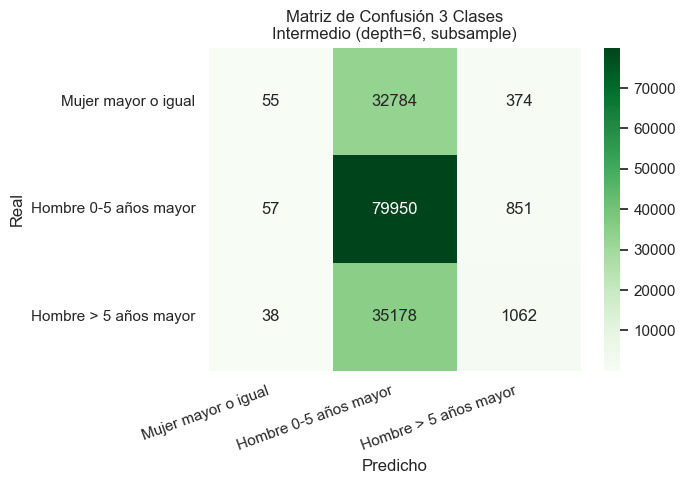


Classification Report:
                       precision    recall  f1-score   support

Hombre 0-5 años mayor       0.54      0.99      0.70     80858
Hombre > 5 años mayor       0.46      0.03      0.06     36278
  Mujer mayor o igual       0.37      0.00      0.00     33213

             accuracy                           0.54    150349
            macro avg       0.46      0.34      0.25    150349
         weighted avg       0.48      0.54      0.39    150349



In [19]:
best_idx3   = df_results_3['F1-weighted'].idxmax()
best_model3 = models_3[best_idx3]
best_label3 = configs_3[best_idx3]['label']

y_pred3 = best_model3.predict(X3_test)
y_pred3_labels = le3.inverse_transform(y_pred3)
y_test3_labels = le3.inverse_transform(y3_test)

cm3 = confusion_matrix(y_test3_labels, y_pred3_labels, labels=labels3)

plt.figure(figsize=(7, 5))
sns.heatmap(cm3, annot=True, fmt='d', cmap='Greens',
            xticklabels=labels3, yticklabels=labels3)
plt.title(f'Matriz de Confusión 3 Clases\n{best_label3}')
plt.ylabel('Real'); plt.xlabel('Predicho')
plt.xticks(rotation=20, ha='right')
plt.tight_layout()
plt.savefig('xgb_confusion_3clases.png', bbox_inches='tight')
plt.show()

print("\nClassification Report:")
print(classification_report(y_test3_labels, y_pred3_labels, zero_division=0))

---
## 🔹 Comparación Global de Modelos XGBoost

In [20]:
print("=" * 68)
print("COMPARACIÓN GLOBAL — XGBoost")
print("=" * 68)

best_r = df_results_reg.loc[df_results_reg['R²'].idxmax()]
best_5 = df_results_5.loc[df_results_5['F1-weighted'].idxmax()]
best_3 = df_results_3.loc[df_results_3['F1-weighted'].idxmax()]

print(f"\n🚀 REGRESIÓN — {best_r['Modelo']}")
print(f"   MAE ={best_r['MAE']:.3f} años")
print(f"   RMSE={best_r['RMSE']:.3f} años")
print(f"   R²  ={best_r['R²']:.4f}")

print(f"\n🚀 CLASIFICACIÓN 5 CLASES — {best_5['Modelo']}")
print(f"   Accuracy   ={best_5['Accuracy']:.3f}")
print(f"   F1-weighted={best_5['F1-weighted']:.3f}")

print(f"\n🚀 CLASIFICACIÓN 3 CLASES — {best_3['Modelo']}")
print(f"   Accuracy   ={best_3['Accuracy']:.3f}")
print(f"   F1-weighted={best_3['F1-weighted']:.3f}")

COMPARACIÓN GLOBAL — XGBoost

🚀 REGRESIÓN — Avanzado (300 est, lr=0.03, depth=8, reg.)
   MAE =3.972 años
   RMSE=5.818 años
   R²  =0.0367

🚀 CLASIFICACIÓN 5 CLASES — Intermedio + sample_weight
   Accuracy   =0.300
   F1-weighted=0.291

🚀 CLASIFICACIÓN 3 CLASES — Intermedio (depth=6, subsample)
   Accuracy   =0.539
   F1-weighted=0.390


---
## 📊 Importancia de Variables — Top 15

XGBoost calcula la importancia de las variables usando el **gain** promedio: cuánto mejora la función de pérdida cada vez que esa variable es usada en un split, promediado sobre todos los árboles del ensemble.

Esto es diferente a la frecuencia de uso (que favorece variables con muchos valores posibles) y a la cobertura (número de muestras afectadas por splits).

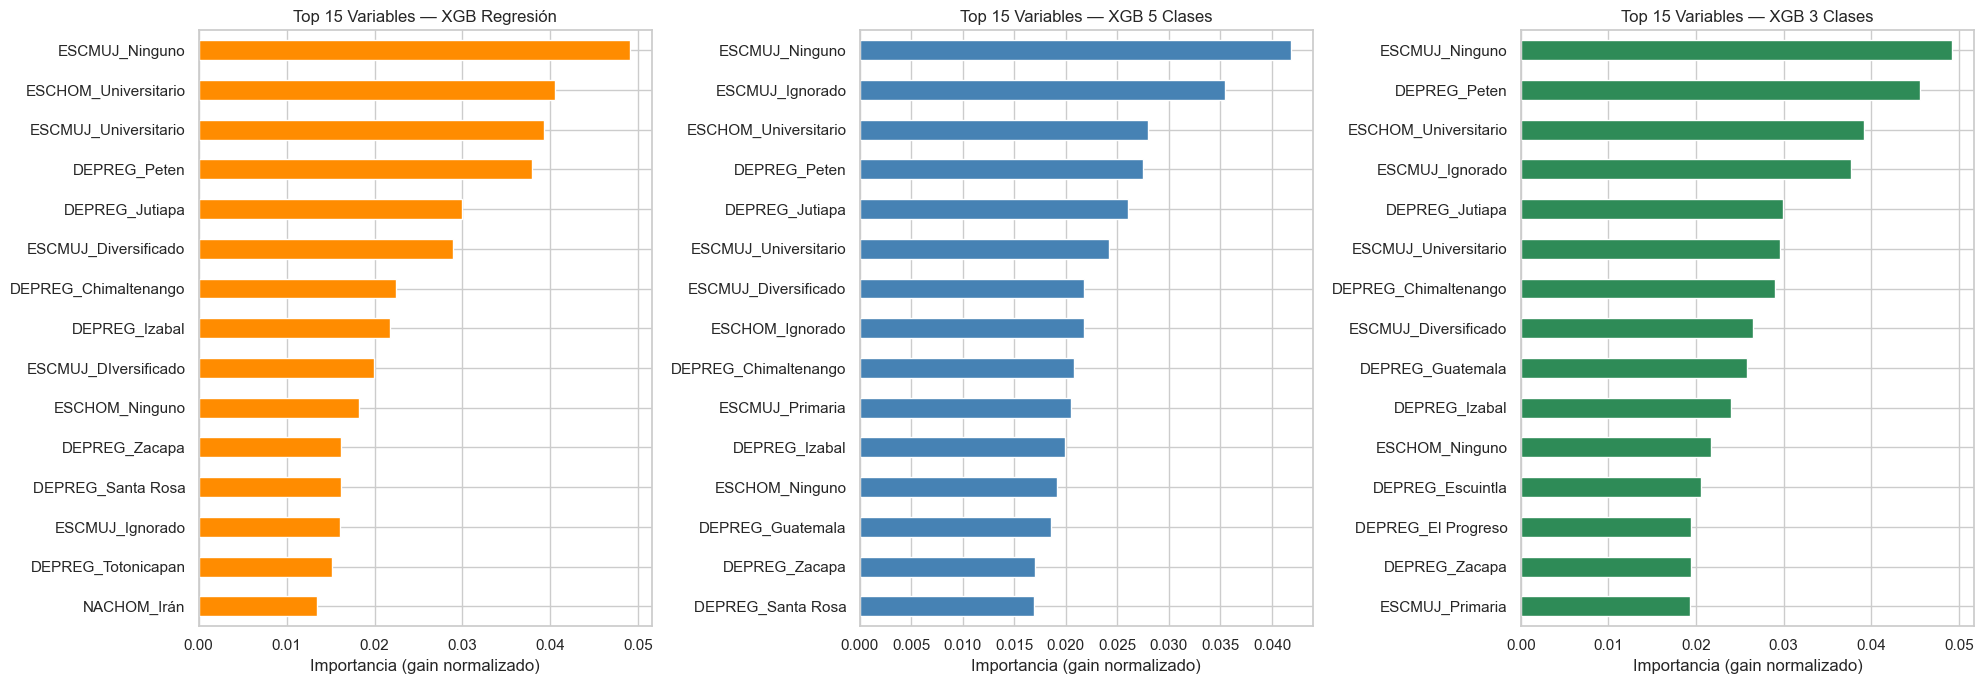

In [21]:
fig, axes = plt.subplots(1, 3, figsize=(20, 7))

for ax, model, title, color in [
    (axes[0], best_model_reg, 'Regresión',     'darkorange'),
    (axes[1], best_model5,    '5 Clases',      'steelblue'),
    (axes[2], best_model3,    '3 Clases',      'seagreen'),
]:
    imp = pd.Series(model.feature_importances_, index=X.columns).nlargest(15)
    imp.sort_values().plot(kind='barh', ax=ax, color=color, edgecolor='white')
    ax.set_title(f'Top 15 Variables — XGB {title}')
    ax.set_xlabel('Importancia (gain normalizado)')

plt.tight_layout()
plt.savefig('xgb_importancia_global.png', bbox_inches='tight')
plt.show()

In [22]:
# Tabla comparativa: variables más importantes en los 3 modelos
top5_r = pd.Series(best_model_reg.feature_importances_, index=X.columns).nlargest(5)
top5_5 = pd.Series(best_model5.feature_importances_,   index=X.columns).nlargest(5)
top5_3 = pd.Series(best_model3.feature_importances_,   index=X.columns).nlargest(5)

comparison_imp = pd.DataFrame({
    'Regresión':     top5_r.index.tolist(),
    'Clasif. 5cls':  top5_5.index.tolist(),
    'Clasif. 3cls':  top5_3.index.tolist(),
}, index=[f'Top {i+1}' for i in range(5)])

print("Top 5 variables más importantes por modelo:")
print(comparison_imp.to_string())

Top 5 variables más importantes por modelo:
                  Regresión          Clasif. 5cls          Clasif. 3cls
Top 1        ESCMUJ_Ninguno        ESCMUJ_Ninguno        ESCMUJ_Ninguno
Top 2  ESCHOM_Universitario       ESCMUJ_Ignorado          DEPREG_Peten
Top 3  ESCMUJ_Universitario  ESCHOM_Universitario  ESCHOM_Universitario
Top 4          DEPREG_Peten          DEPREG_Peten       ESCMUJ_Ignorado
Top 5        DEPREG_Jutiapa        DEPREG_Jutiapa        DEPREG_Jutiapa


---
## 🧠 Análisis Final

### ¿XGBoost supera a Random Forest?

En general, sí — especialmente en:
- **Datasets medianos** (como este, ~20k registros)
- Cuando hay **relaciones complejas** entre variables
- Con **tuning adecuado** de hiperparámetros

Sin embargo, la diferencia puede ser marginal si Random Forest ya está bien ajustado. XGBoost requiere más cuidado: un `learning_rate` alto sin suficientes estimadores puede sobreajustar.

### ¿3 clases vs 5 clases?

| Aspecto | 5 clases | 3 clases |
|---|---|---|
| Granularidad | ✅ Mayor detalle | ❌ Menor detalle |
| Desbalance | ⚠️ Severo (clase 2-3 años) | ✅ Más equilibrado |
| F1-weighted | Más bajo | Más alto |
| Utilidad práctica | Análisis fino | Decisión rápida |

**Recomendación:** usar 3 clases para modelos productivos, 5 clases para análisis exploratorio detallado.

### ¿Qué modelo generaliza mejor?

El modelo **Avanzado** (300 estimadores, learning_rate bajo, regularización) suele generalizar mejor porque:
1. Más árboles → promedia sobre más predictores
2. `learning_rate` bajo → cada árbol contribuye poco, reduciendo overfitting
3. `min_child_weight` alto → hojas más grandes, menos memorización

### Comparación con modelos anteriores

| Modelo | Tipo | F1-3cls (approx) | Interpretabilidad |
|---|---|---|---|
| Decision Tree | Árbol individual | Moderado | ⭐⭐⭐⭐⭐ |
| Random Forest | Bagging | Alto | ⭐⭐⭐ |
| Regresión Logística | Lineal | Moderado | ⭐⭐⭐⭐⭐ |
| **XGBoost** | **Boosting** | **Más alto** | ⭐⭐ |

---

## 🧾 Conclusiones

### Variables más influyentes

Las variables de **educación** (`ESCHOM`, `ESCMUJ`) y **departamento de registro** (`DEPREG`) aparecen consistentemente en el top de importancia en todos los modelos. Esto sugiere que el contexto geográfico y el nivel educativo son determinantes del patrón de diferencia de edades en el matrimonio.

### Ventajas de XGBoost

1. **Alto rendimiento:** supera a otros modelos en datasets complejos
2. **Manejo de no linealidad:** captura interacciones complejas automáticamente
3. **Regularización integrada:** `lambda`, `alpha`, `min_child_weight` reducen overfitting
4. **Flexibilidad:** soporta funciones de pérdida personalizadas
5. **Velocidad:** implementado en C++ con paralelización por nivel de árbol

### Limitaciones

1. **Menor interpretabilidad:** difícil explicar por qué predice un valor específico
2. **Tuning complejo:** muchos hiperparámetros que interactúan entre sí
3. **Sensible a outliers** en regresión (puede memorizar valores extremos)
4. **Sin manejo nativo de desbalance multiclase:** requiere `sample_weight` manual

### Mejoras propuestas

| Mejora | Impacto esperado |
|---|---|
| `GridSearchCV` / `Optuna` para tuning | Alto — puede mejorar F1 significativamente |
| Early stopping (`early_stopping_rounds`) | Evita sobreentrenamiento automáticamente |
| SHAP values para interpretabilidad | Explica predicciones individuales |
| Feature engineering (interacciones) | Puede revelar patrones no capturados |
| `XGBClassifier` con `tree_method='hist'` | Más rápido en datasets grandes |